In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense, TimeDistributed
from keras.losses import SparseCategoricalCrossentropy
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pickle

In [ ]:
df = pd.read_csv('../data/protein.csv')
df.head()


,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa,Exptl.,resolution,R-factor,FreeRvalue
0,1FV1,F,NPVVHFFKNIVTPRTPPPSQ,CCCCCBCCCCCCCCCCCCCC,CCCCCECCCCCCCCCCCCCC,20,False,XRAY,1.90,0.23,0.27
1,1LM8,H,DLDLEMLAPYIPMDDDFQLR,CCCCCCCCCBCCSCCCEECC,CCCCCCCCCECCCCCCEECC,20,False,XRAY,1.85,0.20,0.24
2,1O06,A,EEDPDLKAAIQESLREAEEA,CCCHHHHHHHHHHHHHHHTC,CCCHHHHHHHHHHHHHHHCC,20,False,XRAY,1.45,0.19,0.22
3,1QOW,D,CTFTLPGGGGVCTLTSECI*,CCTTSCTTCSSTTSSTTCCC,CCCCCCCCCCCCCCCCCCCC,20,True,XRAY,1.06,0.14,1.00
4,1RDQ,I,TTYADFIASGRTGRRNAIHD,CHHHHHHTSSCSSCCCCEEC,CHHHHHHCCCCCCCCCCEEC,20,False,XRAY,1.26,0.13,0.16


In [3]:
df = df[['seq', 'sst3', 'has_nonstd_aa']]

In [4]:
df = df[df["has_nonstd_aa"] == False]

In [5]:
df.sample(2)

,seq,sst3,has_nonstd_aa
8545,MASIDKQQIAASVPQRGFFGHPKGLFTLFFTEFWERFSYYGMRAIL...,CCCCCHHHHHCCCCCCEECCEEHHHHHHHHHHHHHHHHHHHHHHHH...,False
3221,MKIYIQPLSVNSHTVEVLANSLPKIFNAEVFVLPASDVSLKCYNAS...,CEEEEEEECCCHHHHHHHHHHHHHHHCCEEEECCCECCCHHHEECC...,False


### **Encoding time**

In [6]:
#tokens for input sequence
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
aa_id = {aa : i+1 for i, aa in enumerate(amino_acids)}
id_aa = {i : aa for aa, i in aa_id.items()}
pad_ID = 0

#tokens for output 
ss_id = {'H': 0, 'E': 1, 'C': 2}
id_ss = {v : k for k, v in ss_id.items()}

In [ ]:
class SequenceEncoder:
    def __init__(self, aa_id, id_aa):
        self.aa_id = aa_id
        self.id_aa= id_aa
    
    def encode(self, sequence):
        return [self.aa_id[aa] for aa in sequence]
    
    def decode(self, encoded_sequence):
        return [self.id_aa[id] for id in encoded_sequence if id != pad_ID]
    
    
class LabelEncoder:
    def __init__(self, ss_id, id_ss):
        self.ss_id = ss_id
        self.id_ss = id_ss
    
    def encode(self, label_sequence):
        return [self.ss_id[s] for s in label_sequence]
    
    def decodel(self, encoded_label):
        return [self.id_ss[a] for a in encoded_label if a in self.id_ss]

In [8]:
seq_encoder = SequenceEncoder(aa_id, id_aa)
label_encoder = LabelEncoder(ss_id, id_ss)

df['seq_encoded'] = df['seq'].apply(seq_encoder.encode)
df['sst3_encoded'] = df['sst3'].apply(label_encoder.encode)

In [9]:
df.sample(2)

,seq,sst3,has_nonstd_aa,seq_encoded,sst3_encoded
2017,MEHVAFGSEDIENTLAKMDDGQLDGLAFGAIQLDGDGNILQYNAAE...,CCCCCCCCCCHHHHCCCCCHHHHCCCCCEEEEEECCCEEEEECHHH...,False,"[11, 4, 7, 18, 1, 5, 6, 16, 4, 3, 8, 4, 12, 17...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, ..."
7575,CDEDETTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVMV...,CCCCCCCCEEEEECCCEEEEEECCCCCCCEEEECCEEEECCCCCCC...,False,"[2, 3, 4, 3, 4, 17, 17, 1, 10, 18, 2, 3, 12, 6...","[2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, ..."


### **Dataset splitting and model training**

In [10]:
x = df['seq_encoded']
y = df['sst3_encoded']
x

0       [12, 13, 18, 18, 7, 5, 5, 9, 12, 8, 18, 17, 13...
1       [3, 10, 3, 10, 4, 11, 10, 1, 13, 20, 8, 13, 11...
2       [4, 4, 3, 13, 3, 10, 9, 1, 1, 8, 14, 4, 16, 10...
4       [17, 17, 20, 1, 3, 5, 8, 1, 16, 6, 15, 17, 6, ...
5       [14, 3, 16, 15, 15, 16, 1, 3, 1, 10, 10, 15, 1...
                              ...                        
9073    [6, 3, 6, 10, 18, 13, 15, 6, 16, 7, 11, 11, 4,...
9074    [6, 16, 7, 11, 17, 14, 5, 4, 6, 5, 17, 12, 10,...
9075    [6, 16, 6, 7, 11, 3, 9, 9, 20, 16, 8, 6, 10, 1...
9076    [16, 12, 1, 11, 9, 8, 16, 9, 18, 15, 4, 4, 12,...
9077    [6, 16, 7, 11, 12, 5, 9, 8, 10, 13, 8, 1, 8, 3...
Name: seq_encoded, Length: 8994, dtype: object

In [11]:
WINDOW_SIZE = 17
HALF_W = WINDOW_SIZE // 2

X_windows = []
y_windows = []

for seq, labels in zip(df["seq_encoded"], df["sst3_encoded"]):
    seq_len = len(seq)

    for i in range(seq_len):
        left = max(0, i - HALF_W)
        right = min(seq_len, i + HALF_W + 1)

        window = seq[left:right]

        # pad window if near edges
        if len(window) < WINDOW_SIZE:
            pad_left = max(0, HALF_W - i)
            pad_right = WINDOW_SIZE - len(window) - pad_left
            window = [pad_ID] * pad_left + window + [pad_ID] * pad_right

        X_windows.append(window)
        y_windows.append(labels[i])

In [12]:
x = np.array(X_windows)
y = np.array(y_windows)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x.shape, y.shape

((2195387, 17), (2195387,))

In [ ]:
# # doing padding because sequences have variable length and batches require equal length tensors
# max_len = max(max(len(seq) for seq in x_train), max(len(seq) for seq in x_test))

# x_train_pad = pad_sequences(x_train, maxlen=max_len, padding='post', value=pad_ID)
# x_test_pad = pad_sequences(x_test, maxlen=max_len, padding='post', value=pad_ID)

# #padding for labels
# y_train_pad = pad_sequences(y_train, maxlen=max_len, padding='post', value=-1)
# y_test_pad = pad_sequences(y_test, maxlen=max_len, padding='post', value=-1)

# train_mask = (y_train_pad != -1).astype("float32")
# test_mask   = (y_test_pad != -1).astype("float32")


# y_train_safe = np.where(y_train_pad == -1, 0, y_train_pad)
# y_test_safe   = np.where(y_test_pad   == -1, 0, y_test_pad)

In [18]:
model = Sequential([
    Embedding(
        input_dim= len(aa_id) + 1,
        output_dim = 64,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dense(3, activation="softmax")
])

In [19]:
model.compile(
    optimizer="adam",
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

In [21]:
print("Max sequence length:", max(len(x) for x in x_train))

Max sequence length: 17


In [22]:
# history = model.fit(
#     x_train_pad,
#     y_train_safe,
#     sample_weight=train_mask,
#     validation_data=(x_test_pad, y_test_safe, test_mask),
#     epochs=10,
#     batch_size=32,
#     callbacks=callbacks
# )

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/10
54885/54885 ━━━━━━━━━━━━━━━━━━━━ 577s 10ms/step - accuracy: 0.6755 - loss: 0.7430 - val_accuracy: 0.6887 - val_loss: 0.7190 - learning_rate: 0.0010
Epoch 2/10
54885/54885 ━━━━━━━━━━━━━━━━━━━━ 681s 12ms/step - accuracy: 0.6936 - loss: 0.7080 - val_accuracy: 0.6963 - val_loss: 0.7025 - learning_rate: 0.0010
Epoch 3/10
54885/54885 ━━━━━━━━━━━━━━━━━━━━ 833s 15ms/step - accuracy: 0.6992 - loss: 0.6957 - val_accuracy: 0.7001 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 4/10
54885/54885 ━━━━━━━━━━━━━━━━━━━━ 762s 14ms/step - accuracy: 0.7029 - loss: 0.6876 - val_accuracy: 0.7006 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 5/10
54885/54885 ━━━━━━━━━━━━━━━━━━━━ 1139s 21ms/step - accuracy: 0.7062 - loss: 0.6813 - val_accuracy: 0.7027 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 6/10
54885/54885 ━━━━━━━━━━━━━━━━━━━━ 1223s 22ms/step - accuracy: 0.7084 - loss: 0.6764 - val_accuracy: 0.7024 - val_loss: 0.6906 - learning_rate: 0.0010
Epoch 7/10
54885/54885 ━━━━━━━━━━━━━━━━━━━━ 

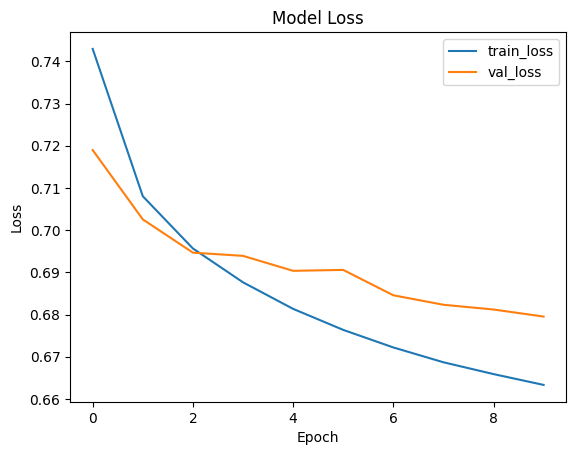

In [23]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [24]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print(f"Validation Q3 Accuracy: {val_acc:.4f}")


13722/13722 ━━━━━━━━━━━━━━━━━━━━ 94s 7ms/step - accuracy: 0.7067 - loss: 0.6795
Validation Q3 Accuracy: 0.7067


In [36]:
def predict_sequence(seq, model, seq_encoder, label_encoder):
    encoded = seq_encoder.encode(seq)
    preds = []

    for i in range(len(encoded)):
        left = max(0, i - HALF_W)
        right = min(len(encoded), i + HALF_W + 1)

        window = encoded[left:right]

        if len(window) < WINDOW_SIZE:
            pad_left = max(0, HALF_W - i)
            pad_right = WINDOW_SIZE - len(window) - pad_left
            window = [pad_ID] * pad_left + window + [pad_ID] * pad_right

        window = np.array(window).reshape(1, -1)
        pred = model.predict(window, verbose=0)
        preds.append(pred.argmax(axis=-1)[0])

    return "".join(label_encoder.decodel(preds))


In [37]:
seq = "MNIDST"
print("Sequence:", seq)
print("Predicted SST3:", predict_sequence(seq, model, seq_encoder, label_encoder))

Sequence: MNIDST
Predicted SST3: CCCCCC


In [43]:
import os

model_dir = os.path.join("..", "model")

if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model.save(os.path.join(model_dir, "protein_bilstm_q3.keras"))

with open(os.path.join(model_dir, "aa_id.pkl"), "wb") as f:
    pickle.dump(aa_id, f)

with open(os.path.join(model_dir, "id_aa.pkl"), "wb") as f:
    pickle.dump(id_aa, f)

with open(os.path.join(model_dir, "ss_id.pkl"), "wb") as f:
    pickle.dump(ss_id, f)

with open(os.path.join(model_dir, "id_ss.pkl"), "wb") as f:
    pickle.dump(id_ss, f)

with open(os.path.join(model_dir, "meta.pkl"), "wb") as f:
    pickle.dump({"window_size": WINDOW_SIZE}, f)
